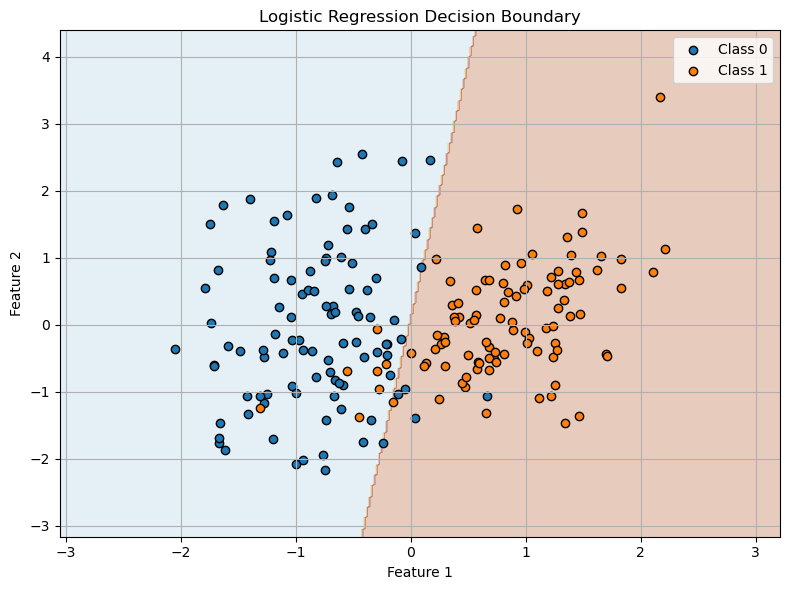

In [1]:
# Visualize decision boundaries for logistic regression using a 2D synthetic dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# -------------------------------------------------------
# Step 1: Generate synthetic 2D classification data
# -------------------------------------------------------
X, y = make_classification(
    n_samples=200,          # total samples
    n_features=2,           # 2D data for plotting
    n_redundant=0,          # no redundant features
    n_clusters_per_class=1,
    class_sep=1.5,          # controls class separation
    random_state=42
)

# -------------------------------------------------------
# Step 2: Standardize features for better convergence
# -------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------------------------------
# Step 3: Train logistic regression model
# -------------------------------------------------------
model = LogisticRegression()
model.fit(X_scaled, y)

# -------------------------------------------------------
# Step 4: Plot decision boundary
# -------------------------------------------------------
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict labels over the meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# -------------------------------------------------------
# Step 5: Plot decision regions + data points
# -------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.3)

# Plot class 0 points
plt.scatter(
    X_scaled[y == 0][:, 0], X_scaled[y == 0][:, 1],
    label="Class 0", edgecolor='k'
)

# Plot class 1 points
plt.scatter(
    X_scaled[y == 1][:, 0], X_scaled[y == 1][:, 1],
    label="Class 1", edgecolor='k'
)

plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save plot
plt.savefig("logistic_decision_boundary.png")
plt.show()
